<a href="https://colab.research.google.com/github/sechan-design/2026-data-science-and-machine-learning/blob/main/%EC%9C%A4%EC%84%B8%EC%B0%AC_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%9D%98_%ED%9D%A9%EC%96%B4%EC%A7%90_%EC%B8%A1%EC%A0%95(%EC%A0%9C%EC%A3%BC_%ED%8F%89%EA%B7%A0%EA%B8%B0%EC%98%A8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ⅱ-1-2 데이터의 흩어짐 측정
### [기본활동] Python으로 산포도, 사분위범위, 분산, 표준편차 구하기


### [1단계] 산포도 그리기


1. 구글 코랩의 file 라이브러리를 사용하여 2025년 제주특별자치도 평균 기온의 데이터세트를 업로드한다.


In [1]:
from google.colab import files
uploaded = files.upload()
csv_file = '2025제주평균기온.csv' #2025년 제주특별자치도 평균기온 파일

Saving 2025제주평균기온.csv to 2025제주평균기온.csv


2. 업로드한 데이터세트를 불러와 판다스 라이브러리를 사용하여 데이터 프레임(df)에 저장하고 출력한다.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(csv_file, encoding ='cp949')
df

,일자,평균기온
0,2025-01-01,7.6
1,2025-01-02,8.5
2,2025-01-03,6.0
3,2025-01-04,6.1
4,2025-01-05,8.1
...,...,...
360,2025-12-27,4.0
361,2025-12-28,8.3
362,2025-12-29,12.4
363,2025-12-30,8.8


In [4]:
type(df['일자'][0])

str

### Datetime 컬럼 연산 예시

`일자` 컬럼이 `datetime` 타입으로 변환되었다고 가정하고, 이 컬럼을 사용하여 다양한 연산들을 수행할 수 있습니다. 먼저 `일자` 컬럼이 `datetime` 타입인지 확인하고, 아니면 변환해줍니다.

In [17]:
df['일자'] = pd.to_datetime(df['일자'])
df['연도'] = df['일자'].dt.year
df['월'] = df['일자'].dt.month
df['일'] = df['일자'].dt.day
df['요일'] = df['일자'].dt.dayofweek
df['분기'] = df['일자'].dt.quarter
df['주차'] = df['일자'].dt.isocalendar().week
df

,일자,평균기온,연도,월,일,요일,분기,주차
0,2025-01-01,7.6,2025,1,1,2,1,1
1,2025-01-02,8.5,2025,1,2,3,1,1
2,2025-01-03,6.0,2025,1,3,4,1,1
3,2025-01-04,6.1,2025,1,4,5,1,1
4,2025-01-05,8.1,2025,1,5,6,1,1
...,...,...,...,...,...,...,...,...
360,2025-12-27,4.0,2025,12,27,5,4,52
361,2025-12-28,8.3,2025,12,28,6,4,52
362,2025-12-29,12.4,2025,12,29,0,4,1
363,2025-12-30,8.8,2025,12,30,1,4,1


### 특정 월의 데이터 필터링

`dt.month` 속성을 활용하여 특정 월의 데이터를 쉽게 필터링할 수 있습니다. 예를 들어, 3월의 데이터만 추출해 보겠습니다.

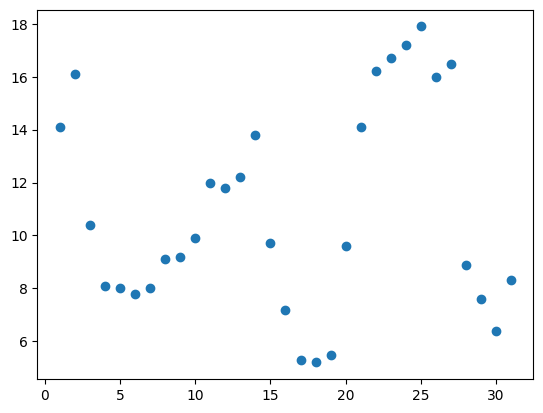

In [27]:
import matplotlib.pyplot as plt
# 3월 데이터 추출
df2 = df[df['월']==3]
plt.scatter(range(1,32),df2['평균기온'])
plt.show()

In [ ]:
#3월 평균기온 산점도로 표시하기


### [2단계] 범위, 사분위간 범위 나타내기
1. [1단계]의 1,2 순서대로 데이터세트를 업로드하고 데이터 프레임에 저장하여 출력한다.

In [28]:
import pandas as pd
df = pd.read_csv(csv_file, encoding ='cp949')
print(df)

             일자  평균기온
0    2025-01-01   7.6
1    2025-01-02   8.5
2    2025-01-03   6.0
3    2025-01-04   6.1
4    2025-01-05   8.1
..          ...   ...
360  2025-12-27   4.0
361  2025-12-28   8.3
362  2025-12-29  12.4
363  2025-12-30   8.8
364  2025-12-31   5.9

[365 rows x 2 columns]


2. 2025년 제주특별자치도 평균기온 파일 데이터세트의 범위, 사분위범위를 확인한다.


In [32]:
#범위 표시
print(f"범위:{max(df['평균기온'] - min(df['평균기온']))}")
#사분위간 범위표시
print(f"사분위 범위:{df['평균기온'].quantile(0.75)-df['평균기온'].quantile(0.25)}")

범위:29.1
사분위 범위:15.200000000000001


### [3단계] 분산, 표준편차 나타내기
1. [1단계]의 1, 2 순서대로 데이터세트를 업로드하고 데이터 프레임에 저장하여 출력한다.
2. 2025년 제주특별자치도  평균 기온의 분산, 표준편차를 확인한다.

In [33]:
#분산
print('분산:',df['평균기온'].var())
#표준편차
print('표준편차',df['평균기온'].std())

분산: 69.3519120879121
표준편차 8.327779541265013
